In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [2]:
class Model(nn.Module):
  def __init__(self, in_features=4, h1=8, h2=9, out_features=3):
    super().__init__()
    self.fc1 = nn.Linear(in_features, h1)
    self.fc2 = nn.Linear(h1, h2)
    self.out = nn.Linear(h2, out_features)

  def forward(self, x):
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.out(x)
    return x

torch.manual_seed(41)
model = Model()

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
url = 'https://gist.githubusercontent.com/netj/8836201/raw/6f9306ad21398ea43cba4f7d537619d0e07d5ae3/iris.csv'
df = pd.read_csv(url)

In [5]:
df['variety'] = df['variety'].replace('Setosa',0.0)
df['variety'] = df['variety'].replace('Versicolor',0.1)
df['variety'] = df['variety'].replace('Virginica',0.2)
df

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,0.2
146,6.3,2.5,5.0,1.9,0.2
147,6.5,3.0,5.2,2.0,0.2
148,6.2,3.4,5.4,2.3,0.2


In [6]:
X = df.drop('variety',axis = 1)
Y = df['variety']

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, Y , test_size=0.2, random_state=41)

In [10]:
_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

In [ ]:
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

In [14]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [15]:
epochs = 100
losses = []
X_train = torch.FloatTensor(X_train)
for i in range(epochs):
  y_pred = model.forward(X_train)
  loss = criterion(y_pred, y_train)
  losses.append(loss.detach().numpy())
  if i % 10 == 0:
    print(f'epoch: {i:2}  loss: {loss.item():10.8f}')
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

epoch:  0  loss: 1.11195862
epoch: 10  loss: 0.49496347
epoch: 20  loss: 0.03981166
epoch: 30  loss: 0.00198642
epoch: 40  loss: 0.00036022
epoch: 50  loss: 0.00016599
epoch: 60  loss: 0.00011908
epoch: 70  loss: 0.00010286
epoch: 80  loss: 0.00009564
epoch: 90  loss: 0.00009147


Text(0.5, 0, 'epoch')

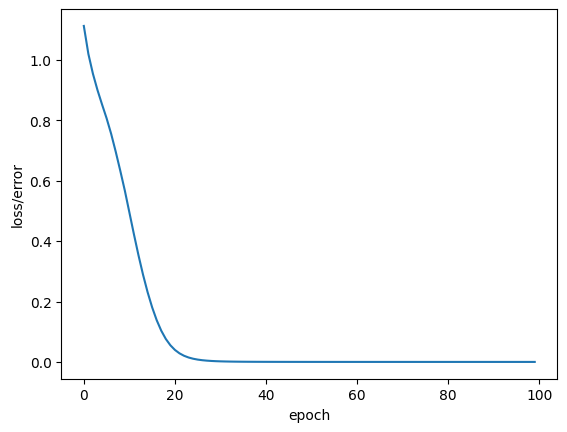

In [16]:
plt.plot(range(epochs),losses)
plt.ylabel("loss/error")
plt.xlabel("epoch")

In [17]:
with torch.no_grad():
  y_eval = model.forward(X_test)
  loss = criterion(y_eval, y_test)

In [18]:
correct = 0
with torch.no_grad():
  for i,data in enumerate(X_test):
    y_val = model.forward(data)

    if y_test[i] == 0.0:
      variety = 'Setosa'
    elif y_test[i] == 0.1:
      variety = 'Versicolor'
    else:
      variety = 'Virginica'
    print(f'{i+1}. {str(y_val):25} \t {y_test[i]}')
    if y_val.argmax().item() == y_test[i]:
      correct += 1
print(f'\n{correct} out of {len(y_test)} = {100*correct/len(y_test):.2f}% correct')

1. tensor([ 7.3390, -5.2881, -3.1515]) 	 0
2. tensor([ 8.1190, -5.8880, -3.4754]) 	 0
3. tensor([ 9.1938, -6.7023, -3.9079]) 	 0
4. tensor([ 7.5955, -5.4794, -3.2513]) 	 0
5. tensor([ 8.4335, -6.1239, -3.5993]) 	 0
6. tensor([ 7.3731, -5.3047, -3.1548]) 	 0
7. tensor([ 7.7902, -5.6310, -3.3342]) 	 0
8. tensor([ 7.7204, -5.5760, -3.3038]) 	 0
9. tensor([ 8.1505, -5.9077, -3.4834]) 	 0
10. tensor([ 8.6464, -6.2905, -3.6909]) 	 0
11. tensor([ 7.7731, -5.6196, -3.3291]) 	 0
12. tensor([ 6.1558, -4.3667, -2.6279]) 	 0
13. tensor([ 5.5162, -3.8840, -2.3699]) 	 0
14. tensor([ 6.2464, -4.4471, -2.6970]) 	 0
15. tensor([ 6.2450, -4.4375, -2.6687]) 	 0
16. tensor([ 7.7780, -5.6213, -3.3288]) 	 0
17. tensor([ 5.8561, -4.1371, -2.5149]) 	 0
18. tensor([ 7.5758, -5.4701, -3.2497]) 	 0
19. tensor([ 6.0450, -4.2801, -2.5862]) 	 0
20. tensor([ 5.3718, -3.7814, -2.2995]) 	 0
21. tensor([ 6.6864, -4.7817, -2.8754]) 	 0
22. tensor([ 8.6719, -6.3077, -3.6988]) 	 0
23. tensor([ 6.2711, -4.4601, -2.6774]) 	

In [20]:
new_iris = torch.tensor([4.7,3.2,2.3,0.2])


In [21]:
with torch.no_grad():
  print(model.forward(new_iris))
  print(model.forward(new_iris).argmax().item())

tensor([ 5.9557, -4.2155, -2.5673])
0


In [22]:
torch.save(model.state_dict(), 'iris_model.pt')

In [23]:
new_model = Model()
new_model.load_state_dict(torch.load('iris_model.pt'))

<All keys matched successfully>

In [24]:
new_model.eval()


Model(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=9, bias=True)
  (out): Linear(in_features=9, out_features=3, bias=True)
)